# Retail Sales Data Analysis using Python

## 1. Import Libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
# Load dataset

df = pd.read_csv("sales_data.csv")

In [5]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


## 3. Dataset Overview

In [6]:
# Check dataset shape

df.shape

(1000, 14)

In [7]:
# Display first 5 rows

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [8]:
# Display first 5 rows

df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


## 4. Data Cleaning

In [9]:
# Check missing values

df.isnull().sum()

,0
Product_ID,0
Sale_Date,0
Sales_Rep,0
Region,0
Sales_Amount,0
Quantity_Sold,0
Product_Category,0
Unit_Cost,0
Unit_Price,0
Customer_Type,0


In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
df.groupby("Region")["Sales_Amount"].sum()

,Sales_Amount
Region,
East,1259792.93
North,1369612.51
South,1154250.86
West,1235608.93


In [12]:
df["Sales_Amount"].max()

9989.04

In [13]:
df.groupby("Product_Category")["Sales_Amount"].sum()

,Sales_Amount
Product_Category,
Clothing,1313474.36
Electronics,1243499.64
Food,1201773.54
Furniture,1260517.69


In [14]:
df.groupby("Sale_Date")["Sales_Amount"].sum()

,Sales_Amount
Sale_Date,
01-01-2023,14141.12
01-01-2024,19328.01
01-02-2023,3826.41
01-03-2023,13787.11
01-06-2023,22609.42
...,...
31-05-2023,2579.63
31-07-2023,8090.84
31-08-2023,21855.10


## 5. Exploratory Data Analysis & Visualizations

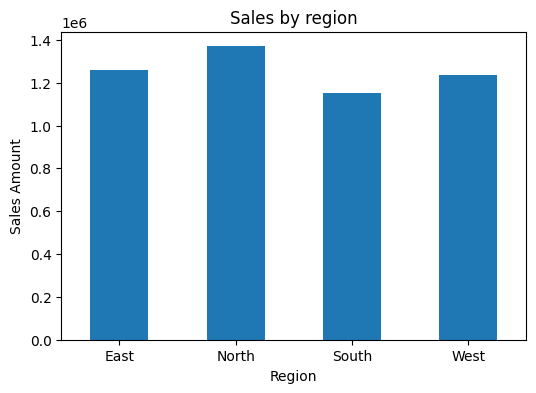

In [16]:
# Sales by region bar chart

region_sales = df.groupby("Region")["Sales_Amount"].sum()

plt.figure(figsize=(6,4))
region_sales.plot(kind="bar")
plt.title("Sales by region")
plt.xlabel("Region")
plt.ylabel("Sales Amount")
plt.xticks(rotation=0)
plt.show()

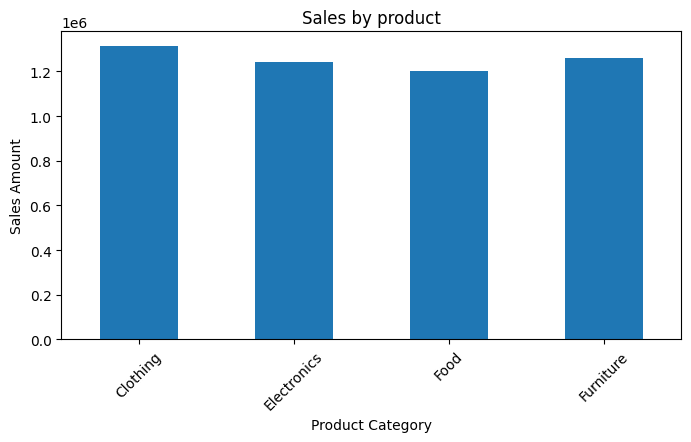

In [17]:
# Sales by product bar chart

product_sales = df.groupby("Product_Category")["Sales_Amount"].sum()

plt.figure(figsize=(8,4))
product_sales.plot(kind="bar")
plt.title("Sales by product")
plt.xlabel("Product Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

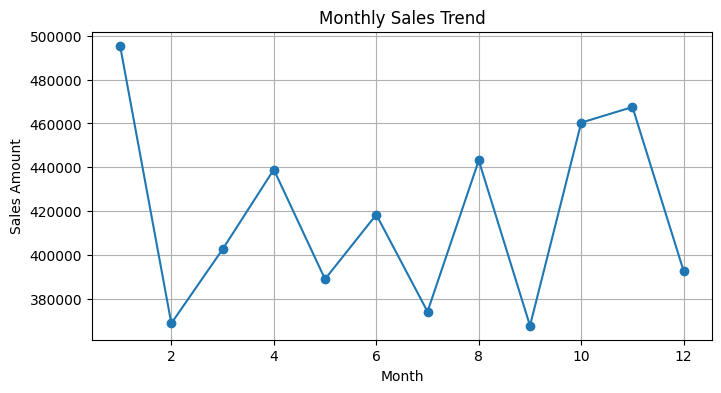

In [19]:
# Monthly sales trend by line chart

df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], dayfirst=True)
monthly_sales = df.groupby(df["Sale_Date"].dt.month)["Sales_Amount"].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid()
plt.show()

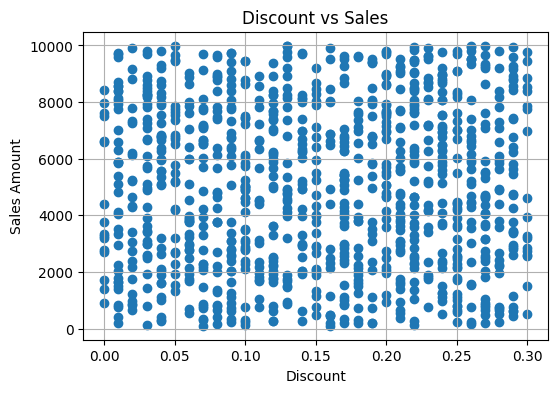

In [22]:
# Discount vs Sales by Scatter Plot

plt.figure(figsize=(6,4))
plt.scatter(df["Discount"], df["Sales_Amount"])
plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales Amount")
plt.grid()
plt.show()

## 6. Business Insights

In [23]:
df.groupby("Region")["Sales_Amount"].sum().idxmax()

'North'

In [24]:
df.groupby("Product_Category")["Sales_Amount"].sum().idxmax()

'Clothing'

In [25]:
df.groupby(df["Sale_Date"].dt.month)["Sales_Amount"].sum().idxmax()

np.int32(1)

In [26]:
df.groupby("Sales_Channel")["Sales_Amount"].sum()

,Sales_Amount
Sales_Channel,
Online,2458833.93
Retail,2560431.30


### Key Business Insights

1. North region generated the highest revenue among all regions.

2. Clothing was the top-selling product category.

3. Sales peaked in January, indicating strong customer purchases at the beginning of the year.

4. Retail channel outperformed Online channel in total sales revenue.

## 7. Final Conclusion

This project analyzed retail sales data using Python to identify business trends and performance patterns.

Using Pandas, data cleaning was performed to handle missing values and duplicates. Exploratory Data Analysis (EDA) and visualizations were created using Matplotlib and Seaborn.

Key findings include:
- North region generated the highest revenue
- Clothing was the top-selling category
- Sales peaked in January
- Retail channel performed better than Online

This analysis helps businesses understand sales performance and make data-driven decisions.